# Imports

In [197]:
import sys
import os
from os.path import sep
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm
import seaborn as sns
import pandas as pd

# Local modules
sys.path.append('Documents{0}CEGIS{0}discsim{0}api{0}utils{0}Pre Survey Nested Simulation'.format(sep))
from AS_extract_data_from_dta_file import extract_data_from_dta
import ecd_nested_simulation_functions

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# NHFS-5

## Load data

In [4]:
cd

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [11]:
file_path ='Documents{0}CEGIS{0}DiscSim_figures_and_data{0}NHFS-5 data{0}NHFS-5 data from SP - CORRECT COLUMN NAMES PR{0}IAPR7AFL.DTA'.format(sep)
data = extract_data_from_dta(file_path, convert_categoricals=False)

In [12]:
data

,hhid,hvidx,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,...,hml32b,hml32c,hml32d,hml32e,hml32f,hml32g,hml33,hml34,hml35,hml36
0,0100101305,1,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
1,0100101305,2,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2,0100101305,3,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
3,0100101305,4,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
4,0100101305,5,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843912,3700401592,1,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843913,3700401592,2,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843914,3700401592,3,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843915,3700401592,4,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN


Relevant column labels from .DO file:

label variable hc1      "Child's age in months"

label variable hc1a     "Child's age in days"

label variable hc2      "Child's weight in kilograms (1 decimal)"

label variable hc3      "Child's height in centimeters (1 decimal)"

label variable hc4      "Height/Age percentile"

label variable hc5      "Height/Age standard deviation"

label variable hc6      "Height/Age percent of ref. median"

label variable hc7      "Weight/Age percentile"

label variable hc8      "Weight/Age standard deviation"

label variable hc9      "Weight/Age percent of ref. median"

label variable hc10     "Weight/Height percentile"

label variable hc11     "Weight/Height standard deviation"

label variable hc12     "Weight/Height percent of ref. median"

label variable hc13     "Result of measurement - height/weight"

label variable hc15     "Height: lying or standing"

label variable hc27     "Sex"

## Processing

Values to exclude (from .DO file):

label define HC2     
  9994 "Not present"
  9995 "Refused"
  9996 "Other"
;

label define HC3     
  9994 "Not present"
  9995 "Refused"
  9996 "Other"
;

label define HC4     
  9998 "Flagged cases"
;

label define HC5     
  9998 "Flagged cases"
;

label define HC6     
 99998 "Flagged cases"
;

label define HC7     
  9998 "Flagged cases"
;

label define HC8     
  9998 "Flagged cases"
;

label define HC9     
 99998 "Flagged cases"
;

label define HC10    
  9998 "Flagged cases"
;

label define HC11    
  9998 "Flagged cases"
;

label define HC12    
 99998 "Flagged cases"
;


### Exclude rows with 'Not present', 'Refused', or 'Other' for height or weight

In [30]:
excl_values = [9994, 9995, 9996]
data.drop(data[(data['hc2'].isin(excl_values)) | (data['hc3'].isin(excl_values))].index, inplace=True)

### Exclude rows with 'Flagged cases' for HAP, WAP, HAZ, WAZ, WHP or WHZ

In [33]:
excl_values = [9998]
data.drop(data[(data['hc4'].isin(excl_values)) | (data['hc5'].isin(excl_values)) | (data['hc7'].isin(excl_values)) | (data['hc8'].isin(excl_values)) | (data['hc10'].isin(excl_values))].index, inplace=True)

### Exclude rows with NaN values for age, height or weight

In [131]:
# Drop rows with NaN for hc2, hc3 or hc1a
data.dropna(subset=['hc2', 'hc3', 'hc1a'], inplace=True)

## Get data into lists

In [132]:
age = data['hc1a']
weight = data['hc2']/10
height = data['hc3']/10
hap = data['hc4']
haz = data['hc5']/100
wap = data['hc7']
waz = data['hc8']/100
whp = data['hc10']
whz = data['hc11']/100
lohr = data['hc15'] # Whether height measured lying or standing
sex = data['hc27']


In [133]:
# Print minimum, maximum, mean and standard deviation of age, height, weight, haz, waz and whz.
print("Age: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(age), np.max(age), np.mean(age), np.std(age)))
print("Height: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(height), np.max(height), np.mean(height), np.std(height)))
print("Weight: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(weight), np.max(weight), np.mean(weight), np.std(weight)))
print("HAZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(haz), np.max(haz), np.mean(haz), np.std(haz)))
print("WAZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(waz), np.max(waz), np.mean(waz), np.std(waz)))
print("WHZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(whz), np.max(whz), np.mean(whz), np.std(whz)))


Age: Min = 0.0, Max = 1826.0, Mean = 936.9287669172933, Std = 523.0499086232693
Height: Min = 49.0, Max = 135.2, Mean = 84.51542556390979, Std = 13.753392069974018
Weight: Min = 1.9, Max = 30.3, Mean = 10.94460952380952, Std = 3.3320809525122224
HAZ: Min = -6.0, Max = 6.0, Mean = -1.209155008702718, Std = 1.6290267063420423
WAZ: Min = -5.98, Max = 5.98, Mean = -1.4485813817007167, Std = 1.2298998894575413
WHZ: Min = -4.0, Max = 6.0, Mean = -0.8721085213032584, Std = 1.2670488106121853


## Plot data and fitted normal distributions

HAZ Distribution: mu = -1.396418106948222, std = 1.7158631352178109
WAZ Distribution: mu = -1.448581381700717, std = 1.2298998894575413


Text(0.5, 1.0, 'WAP Distribution')

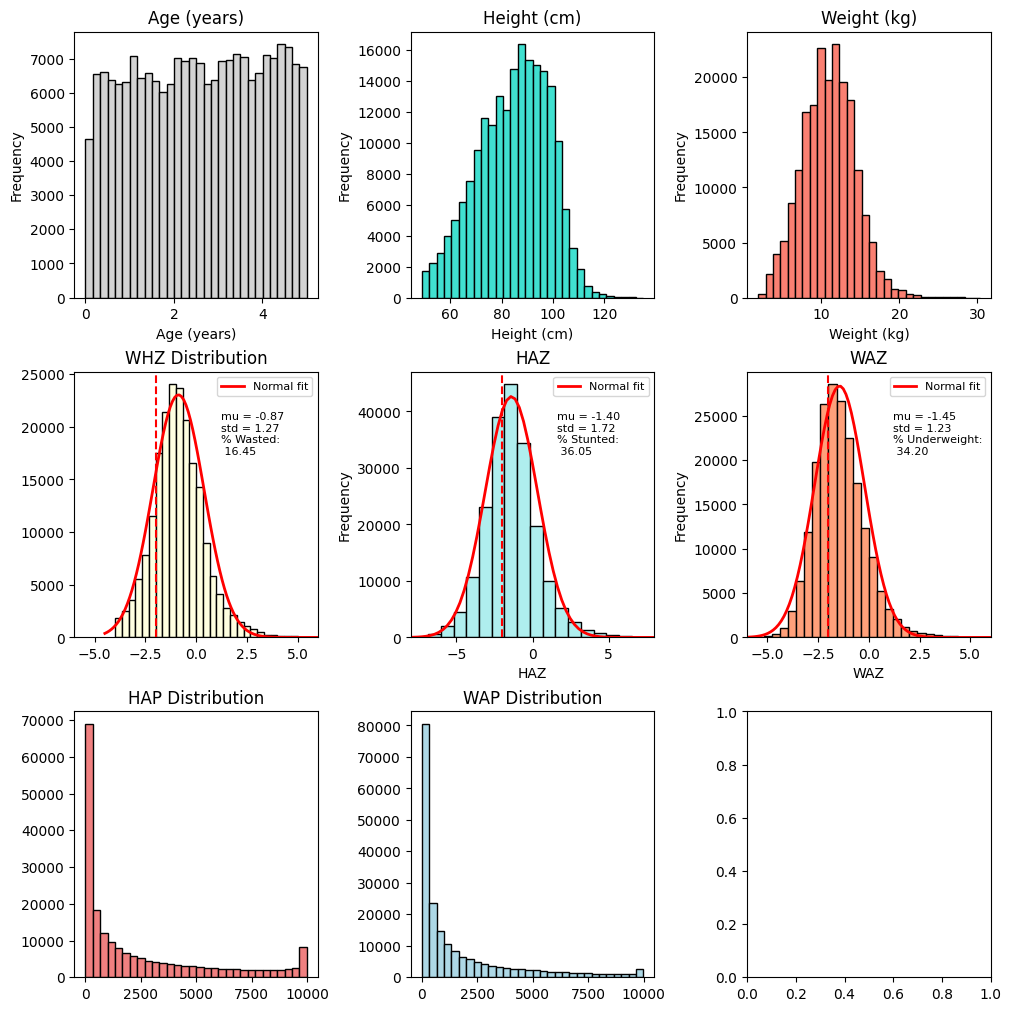

In [212]:
fig, ax = plt.subplots(3, 3, figsize=(10, 10), constrained_layout = True)  

# Age (years)
ax[0, 0].hist(age.dropna()/365, bins=30, color='lightgray', edgecolor='black')
ax[0, 0].set_title('Age (years)')
ax[0, 0].set_xlabel('Age (years)')
ax[0, 0].set_ylabel('Frequency')

# Height distribution
ax[0, 1].hist(height.dropna(), bins=30, color='turquoise', edgecolor='black')
ax[0, 1].set_title('Height (cm)')
ax[0, 1].set_xlabel('Height (cm)')
ax[0, 1].set_ylabel('Frequency')

# Weight distribution
ax[0, 2].hist(weight.dropna(), bins=30, color='salmon', edgecolor='black')
ax[0, 2].set_title('Weight (kg)')
ax[0, 2].set_xlabel('Weight (kg)')
ax[0, 2].set_ylabel('Frequency')

# HAZ distribution
ax[1, 1].hist(haz.dropna(), bins=30, color='paleturquoise', edgecolor='black')
ax[1, 1].set_title('HAZ')
ax[1, 1].set_xlabel('HAZ')
ax[1, 1].set_ylabel('Frequency')

# Fit normal distribution to HAZ and plot overlaying the data
haz_clean = haz.dropna()
mu, std = norm.fit(haz_clean)
xmin, xmax = ax[1, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax[1, 1].plot(x, p * len(haz_clean) * (xmax - xmin) / 30, 'r', linewidth=2, label='Normal fit')
ax[1, 1].set_xlim([-8, 8])
ax[1, 1].legend(fontsize = 8)

# WAZ distribution
ax[1, 2].hist(waz.dropna(), bins=30, color='lightsalmon', edgecolor='black')
ax[1, 2].set_title('WAZ')
ax[1, 2].set_xlabel('WAZ')
ax[1, 2].set_ylabel('Frequency')

# Fit normal distribution to WAZ and plot overlaying the data
waz_clean = waz.dropna()
mu_waz, std_waz = norm.fit(waz_clean)
xmin_waz, xmax_waz = ax[1, 2].get_xlim()
x_waz = np.linspace(xmin_waz, xmax_waz, 100)
p_waz = norm.pdf(x_waz, mu_waz, std_waz)
ax[1, 2].plot(x_waz, p_waz * len(waz_clean) * (xmax_waz - xmin_waz) / 30, 'r', linewidth=2, label='Normal fit')
ax[1, 2].set_xlim([-6, 6])
ax[1, 2].legend(fontsize = 8)

# WHZ distribution
ax[1, 0].hist(whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[1, 0].set_title('WHZ Distribution')

# Print mean and standard deviations of fitted HAZ and WAZ distributions
print(f"HAZ Distribution: mu = {mu}, std = {std}")
print(f"WAZ Distribution: mu = {mu_waz}, std = {std_waz}")

# Fit normal distribution to WHZ and plot overlaying the data
whz_clean = whz.dropna()
mu_whz, std_whz = norm.fit(whz_clean)
xmin_whz, xmax_whz = ax[1, 0].get_xlim()
x_whz = np.linspace(xmin_whz, xmax_whz, 100)
p_whz = norm.pdf(x_whz, mu_whz, std_whz)
ax[1, 0].plot(x_whz, p_whz * len(whz_clean) * (xmax_whz - xmin_whz) / 30, 'r', linewidth=2, label='Normal fit')
ax[1, 0].set_xlim([-6, 6])
ax[1, 0].legend(fontsize = 8)

# Calculate the percentage of stunted, underweight and wasted children, based on haz < -2, waz < -2, whz < -2
percent_stunted = (haz < -2).mean() * 100
percent_underweight = (waz < -2).mean() * 100
percent_wasted = (whz < -2).mean() * 100

# Plot a vertical dashed red line at -2 in each subplot in the second row
ax[1, 0].axvline(x=-2, color='red', linestyle='--')
ax[1, 1].axvline(x=-2, color='red', linestyle='--')
ax[1, 2].axvline(x=-2, color='red', linestyle='--')

# Add text to the plot giving the mean and standard deviation of the fitted distributions, 
# and percentage of stunted, wasted and underweight children in the appropriate plots
ax[1, 1].text(0.6, 0.85, f"mu = {mu:.2f}\nstd = {std:.2f}\n% Stunted:\n {percent_stunted:.2f}", transform=ax[1, 1].transAxes, fontsize=8,
        verticalalignment='top')
ax[1, 2].text(0.6, 0.85, f"mu = {mu_waz:.2f}\nstd = {std_waz:.2f}\n% Underweight:\n {percent_underweight:.2f}", transform=ax[1, 2].transAxes, fontsize=8,
        verticalalignment='top')
ax[1, 0].text(0.6, 0.85, f"mu = {mu_whz:.2f}\nstd = {std_whz:.2f}\n% Wasted:\n {percent_wasted:.2f}", transform=ax[1, 0].transAxes, fontsize=8,
        verticalalignment='top')

# HAP distribution
ax[2, 0].hist(hap.dropna(), bins=30, color='lightcoral', edgecolor='black')
ax[2, 0].set_title('HAP Distribution')

# WAP distribution
ax[2, 1].hist(wap.dropna(), bins=30, color='lightblue', edgecolor='black')
ax[2, 1].set_title('WAP Distribution')


## Plot data along with WHO standard

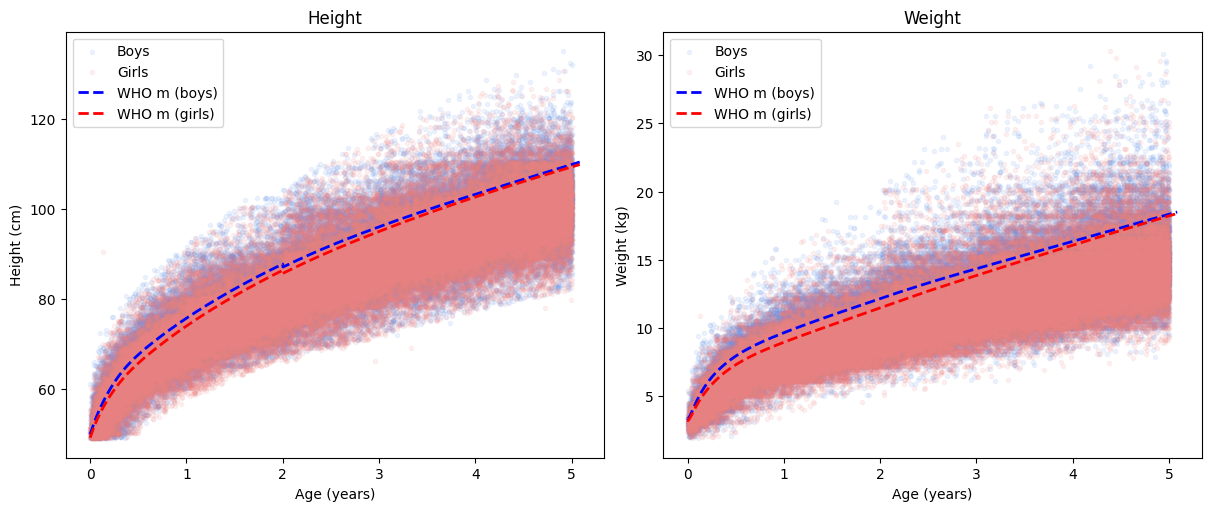

In [188]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout = True)

# Height
boys = sex[sex == 1]
girls = sex[sex == 2]
ax[0].scatter(age[boys.index]/365, height[boys.index], color = 'cornflowerblue', marker = '.', alpha = 0.1, label = 'Boys')
ax[0].scatter(age[girls.index]/365, height[girls.index], color = 'lightcoral', marker = '.', alpha = 0.1, label = 'Girls')

# Plot m from WHO haz parameters as a function of _agedays from WHO growth standards
n_rows = len(haz_params['_agedays'])
ax[0].plot(haz_params['_agedays'][:int(n_rows/2)]/365, haz_params['m'][:int(n_rows/2)], color='b', linewidth=2, linestyle='--',
         label = 'WHO m (boys)')
ax[0].plot(haz_params['_agedays'][int(n_rows/2):] /365, haz_params['m'][int(n_rows/2):], color='r', linewidth=2, linestyle='--',
         label = 'WHO m (girls)')

ax[0].set_xlabel('Age (years)')
ax[0].set_ylabel('Height (cm)')
ax[0].set_title('Height')

ax[0].legend()

# Weight
ax[1].scatter(age[boys.index]/365, weight[boys.index], color = 'cornflowerblue', marker = '.', alpha = 0.1, label = 'Boys')
ax[1].scatter(age[girls.index]/365, weight[girls.index], color = 'lightcoral', marker = '.', alpha = 0.1, label = 'Girls')

# Plot m from WHO waz parameters as a function of _agedays from WHO growth standards
n_rows = len(waz_params['_agedays'])
ax[1].plot(waz_params['_agedays'][:int(n_rows/2)]/365, waz_params['m'][:int(n_rows/2)], color='b', linewidth=2, linestyle='--',
         label = 'WHO m (boys)')
ax[1].plot(waz_params['_agedays'][int(n_rows/2):] /365, waz_params['m'][int(n_rows/2):], color='r', linewidth=2, linestyle='--',
         label = 'WHO m (girls)')

ax[1].set_xlabel('Age (years)')
ax[1].set_ylabel('Weight (kg)')
ax[1].set_title('Weight')

ax[1].legend()

## Calculate HAZ, WAZ and WHZ from height, weight, age and sex

199500it [00:43, 4612.49it/s]
199500it [00:42, 4702.45it/s]


Calculating adjusted heights
Adjusted heights calculated


199500it [00:43, 4586.07it/s]


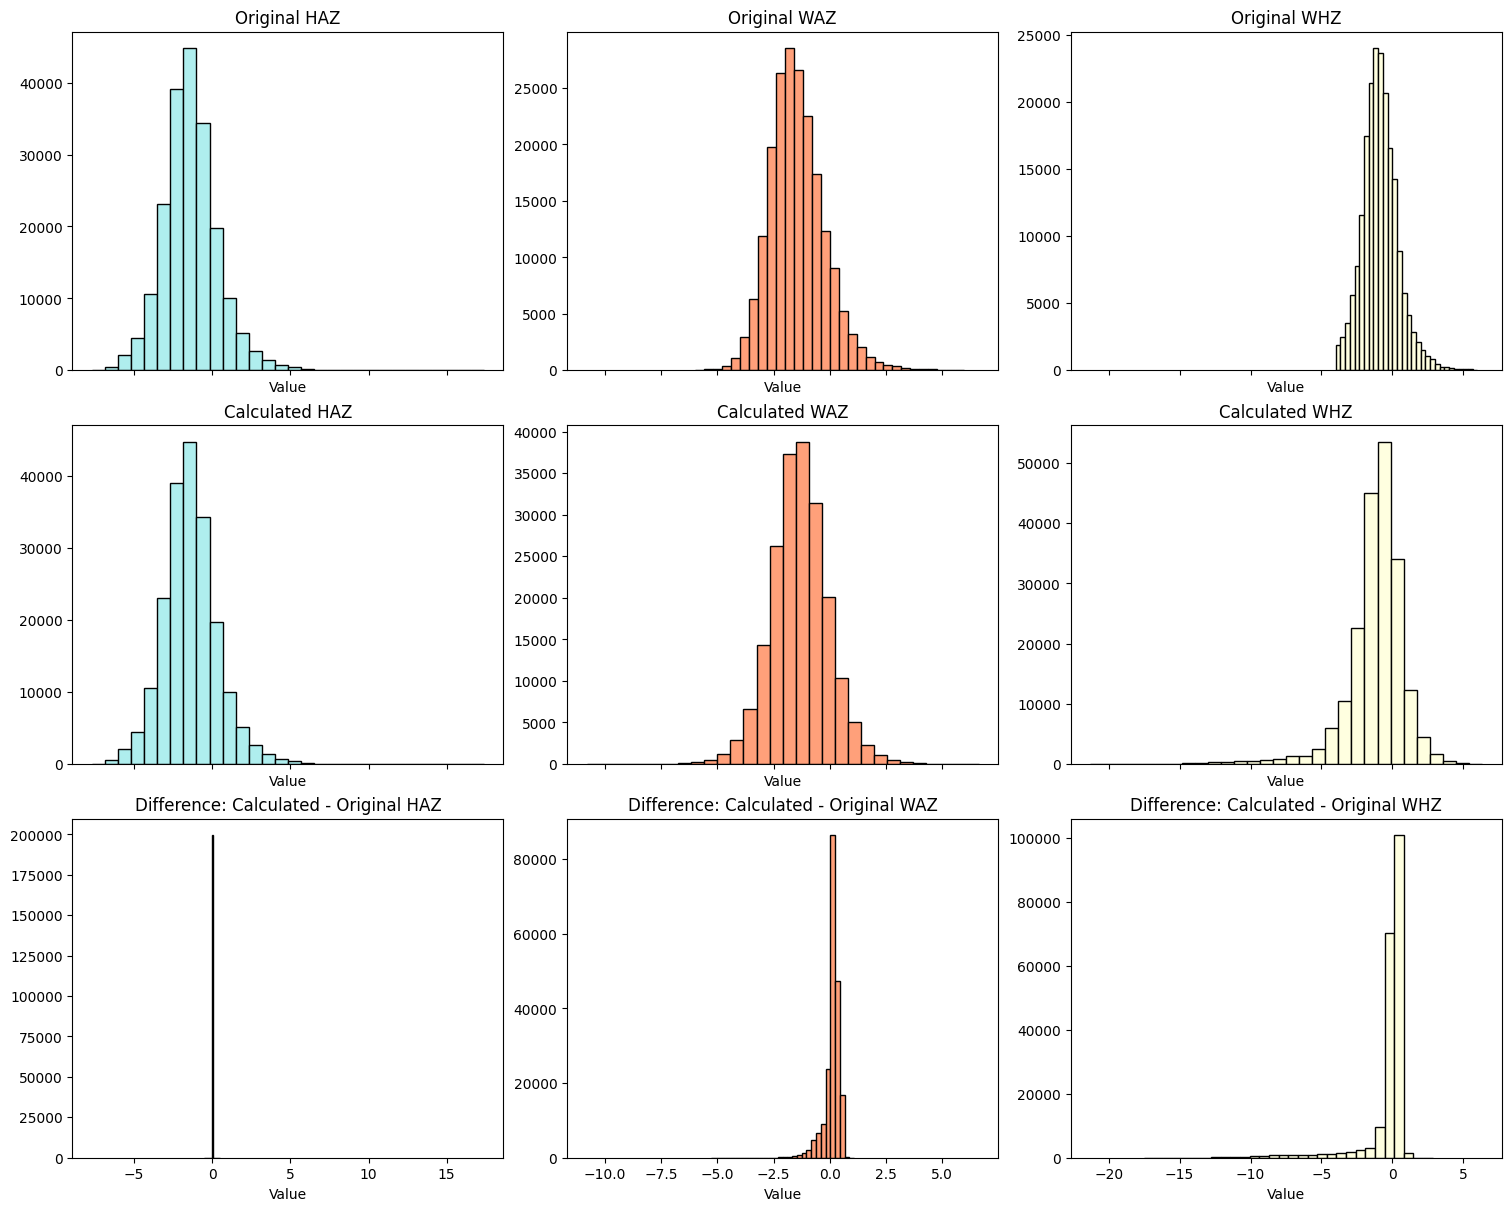

In [206]:
fig, ax = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True, sharex = 'col')

# First row: histograms of original HAZ, WAZ, WHZ
ax[0, 0].hist(haz.dropna(), bins=30, color='paleturquoise', edgecolor='black')
ax[0, 0].set_title('Original HAZ')
ax[0, 1].hist(waz.dropna(), bins=30, color='lightsalmon', edgecolor='black')
ax[0, 1].set_title('Original WAZ')
ax[0, 2].hist(whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[0, 2].set_title('Original WHZ')

# Second row: calculated distributions
calc_haz = ecd_nested_simulation_functions.calculate_haz(height, age, sex, haz_params)
calc_waz = ecd_nested_simulation_functions.calculate_waz(weight, age, sex, waz_params)
calc_whz = ecd_nested_simulation_functions.calculate_whz(height, weight, sex, whz_params)

ax[1, 0].hist(calc_haz.dropna(), bins=30, color='paleturquoise', edgecolor='black')
ax[1, 0].set_title('Calculated HAZ')
ax[1, 1].hist(calc_waz.dropna(), bins=30, color='lightsalmon', edgecolor='black')
ax[1, 1].set_title('Calculated WAZ')
ax[1, 2].hist(calc_whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[1, 2].set_title('Calculated WHZ')

# Third row: distribution of the difference between calculated and original values
# Align indices and drop NaNs for fair comparison
haz_diff = (calc_haz - haz).dropna()
waz_diff = (calc_waz - waz).dropna()
whz_diff = (calc_whz - whz).dropna()

ax[2, 0].hist(haz_diff, bins=30, color='paleturquoise', edgecolor='black')
ax[2, 0].set_title('Difference: Calculated - Original HAZ')
ax[2, 1].hist(waz_diff, bins=30, color='lightsalmon', edgecolor='black')
ax[2, 1].set_title('Difference: Calculated - Original WAZ')
ax[2, 2].hist(whz_diff, bins=30, color='lightyellow', edgecolor='black')
ax[2, 2].set_title('Difference: Calculated - Original WHZ')

for i in range(3):
    for j in range(3):
        ax[i, j].set_xlabel('Value')

# NHTS: Jan - March 2025, 3 districts

## Load data

In [1]:
cd

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Anthropometric measures: WHO parameters

In [161]:
# Load HAZ parameters
filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}lenanthro.dta'.format(os.sep)
haz_params = extract_data_from_dta(filename)

# Load WAZ parameters
filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}weianthro.dta'.format(os.sep)
waz_params = extract_data_from_dta(filename)

# Load WHZ parameters
filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}wfhanthro.dta'.format(os.sep)
whz_params = extract_data_from_dta(filename)

In [182]:
whz_params

,__000001,__000003,l,m,s,lorh
0,1,65.000000,-0.3521,7.432700,0.08217,H
1,1,65.099998,-0.3521,7.456300,0.08216,H
2,1,65.199997,-0.3521,7.479900,0.08216,H
3,1,65.300003,-0.3521,7.503400,0.08215,H
4,1,65.400002,-0.3521,7.526900,0.08214,H
...,...,...,...,...,...,...
1097,2,119.599998,-0.3833,22.644400,0.09812,H
1098,2,119.699997,-0.3833,22.687700,0.09816,H
1099,2,119.800003,-0.3833,22.730900,0.09820,H
1100,2,119.900002,-0.3833,22.774099,0.09824,H


In [73]:
len(np.unique(haz_params['_agedays']))

1857

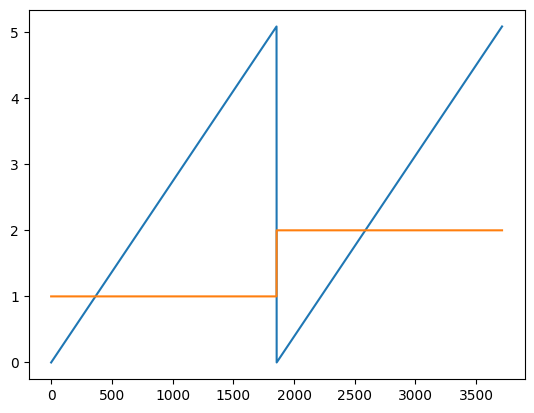

In [77]:
plt.figure()
plt.plot(haz_params['_agedays']/365)
plt.plot(haz_params['__000001'])